# Sonification of Stellar Data: Longer form dataset

GOAL: Inspired by the doppler effect, I want to showcase the relationship between redshift and red filter as a way to demonstrate how the doppler effect works in relation to light and sound. Here are the parameters explained: 
+ Redshift (y-axis): should be represented by pitch. The closer a stellar object is to Earth, the higher in pitch it would be; the farther away, the lower it is in pitch --> I would have to reverse the axis, so I can demonstrate this. 
+ Redfilter (x-axis): Is a representation of how strong the filter should be to filter out blue-green light in order to capture redshift --> a representation of how redshift is an indicator of distance and red filter strength is proportional to redshift, further enahcning and representing distance of a stellar object. 
+ Scale is represented by classes of stellar object: Galaxies are larger objects that will be represented by louder dynamics, with stars being smaller stellar objects represented by softer dynamics. Might consider instrumental representation as well (not sure)

## Start by Loading Data

In [ ]:
import pandas as pd  
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np
from scipy.stats import boxcox

filename = 'star_classification'  #name of csv data file

df = pd.read_csv(filename + '.csv')  #load data as a pandas dataframe

#From there, try and remove values less than 0. How much data will I lose? 
#NOTE: Negative Redshift values are most likely blue shift! Blue shift represents objects moving towards us, so I need to decide on whether I should consider including blue shift objects. 
below_zero = df['redshift'] < 0.0
df  = df[~ below_zero]

#Would prefer if u and g were greater than 0 to help remove outliers that could interfere with distribution
df = df[df['u'] >= 0] 
df = df[df['g'] >= 0]

#Now, let's create a new column: Color shift, normally represent as r-z
df['color_shift'] = df['r'] - df['z']

#Let's try to cut the data in half 

df = df.sample(frac=0.01, random_state = 42)

df.head()


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,color_shift
83993,1.237679e+18,12.029203,-2.840005,23.79050,22.54417,20.46415,19.17183,18.72390,7907,301,3,152,4.920223e+18,GALAXY,0.628968,4370,55534,147,1.74025
88207,1.237661e+18,191.299081,46.247911,20.51730,20.25353,20.25621,20.15044,19.87513,3698,301,1,199,8.350942e+18,QSO,2.080831,7417,56753,518,0.38108
69952,1.237666e+18,239.430247,15.672447,24.76875,18.34331,18.06672,18.01208,18.02010,4674,301,1,243,4.415885e+18,QSO,3.275297,3922,55333,382,0.04662
36629,1.237652e+18,210.542010,65.614699,23.01619,22.05534,20.54336,19.59354,19.16927,1412,301,4,237,7.865590e+18,GALAXY,0.466498,6986,56717,193,1.37409
76178,1.237679e+18,333.215040,3.291091,18.74191,17.14535,16.29889,15.87646,15.51895,7712,301,6,151,4.865187e+18,GALAXY,0.093819,4321,55504,630,0.77994


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 863 entries, 83993 to 31070
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   obj_ID       863 non-null    float64
 1   alpha        863 non-null    float64
 2   delta        863 non-null    float64
 3   u            863 non-null    float64
 4   g            863 non-null    float64
 5   r            863 non-null    float64
 6   i            863 non-null    float64
 7   z            863 non-null    float64
 8   run_ID       863 non-null    int64  
 9   rerun_ID     863 non-null    int64  
 10  cam_col      863 non-null    int64  
 11  field_ID     863 non-null    int64  
 12  spec_obj_ID  863 non-null    float64
 13  class        863 non-null    object 
 14  redshift     863 non-null    float64
 15  plate        863 non-null    int64  
 16  MJD          863 non-null    int64  
 17  fiber_ID     863 non-null    int64  
 18  color_shift  863 non-null    float64
dtypes: floa

In [163]:
#Let's try and remove rerun_ID. 

df = df.drop('rerun_ID', axis = 1)

df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,color_shift
83993,1.237679e+18,12.029203,-2.840005,23.79050,22.54417,20.46415,19.17183,18.72390,7907,3,152,4.920223e+18,GALAXY,0.628968,4370,55534,147,1.74025
88207,1.237661e+18,191.299081,46.247911,20.51730,20.25353,20.25621,20.15044,19.87513,3698,1,199,8.350942e+18,QSO,2.080831,7417,56753,518,0.38108
69952,1.237666e+18,239.430247,15.672447,24.76875,18.34331,18.06672,18.01208,18.02010,4674,1,243,4.415885e+18,QSO,3.275297,3922,55333,382,0.04662
36629,1.237652e+18,210.542010,65.614699,23.01619,22.05534,20.54336,19.59354,19.16927,1412,4,237,7.865590e+18,GALAXY,0.466498,6986,56717,193,1.37409
76178,1.237679e+18,333.215040,3.291091,18.74191,17.14535,16.29889,15.87646,15.51895,7712,6,151,4.865187e+18,GALAXY,0.093819,4321,55504,630,0.77994


In [164]:
#Normalizing distribution using yeo-johnson

from sklearn.preprocessing import PowerTransformer 

pt = PowerTransformer('yeo-johnson', standardize = True)

df['redshift'] = pt.fit_transform(df[['redshift']])
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,color_shift
83993,1.237679e+18,12.029203,-2.840005,23.79050,22.54417,20.46415,19.17183,18.72390,7907,3,152,4.920223e+18,GALAXY,0.411727,4370,55534,147,1.74025
88207,1.237661e+18,191.299081,46.247911,20.51730,20.25353,20.25621,20.15044,19.87513,3698,1,199,8.350942e+18,QSO,1.738432,7417,56753,518,0.38108
69952,1.237666e+18,239.430247,15.672447,24.76875,18.34331,18.06672,18.01208,18.02010,4674,1,243,4.415885e+18,QSO,2.110953,3922,55333,382,0.04662
36629,1.237652e+18,210.542010,65.614699,23.01619,22.05534,20.54336,19.59354,19.16927,1412,4,237,7.865590e+18,GALAXY,0.076429,6986,56717,193,1.37409
76178,1.237679e+18,333.215040,3.291091,18.74191,17.14535,16.29889,15.87646,15.51895,7712,6,151,4.865187e+18,GALAXY,-1.121107,4321,55504,630,0.77994


In [165]:
df.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
color_shift    0
dtype: int64

## 2) Plot Data (Redshift)

So, what do I want to showcase the relationship between? I think one of the most interesting things I noticed about the data when doing some EDA is how redshift can be used as an indicator of distance and age of an object as well. I noticed that the dataset is split into 3 classes of stellar objects: stars, galaxies, and QSOs (Quasi-Stellar Objects). What's particularly interesting is the relationship between redshift and class. QSOs on average tend to have a higher redshift than galaxies and stars, which makes sense because QSOs are the farthest observed objects in the dataset. I think it would be interesting to use class as a scaler to represent how far (or old) stellar objects are based on redshift as a way to represent redshift's ability to indicate time and distance relative to these objects' positions from Earth. 

I can make redshift the y-axis, but if I want to create a long form sonified piece out of this dataset, then I'll have to use unique values from a particular x-axis to properly represent redshift and class. So, what are some options for x-axis? If I just want to showcase the relationship between class and redshift, then I can just use metadata, like obj_ID or spec_obj_ID, otherwise, if I want to do some kind of multivariate analysis, then I can make the x-axis either red filter or near-infrared filter to showcase how redshift increases as the filter itself increases. 

I think the goal of this sonified piece is to showcase redshift's capabilities as an indicator of time and distance when performing stellar classification compared to other colored filters. 

In [166]:
#Once I create a scatter plot, then I can continue with the steps I've done previously for the sonification process.  

#NOTE: With only 0.01 percent of the dataset, I was able to significantly reduce the dataset (randomized to avoid bias of course, to properly map the data onto a sonified piece)

"""I am evaluating this dataset by three types of filters on the y-axis --> red filter, near-infrared, and infrared filters. Basically, there are certain stellar objects that won't be as visible through one filter, which indicates 
that they'll have a higher magnitude using a different filter --> because I'm creating multiple graphs/MIDI files based on class, I might consider having to use differnt filters for each y-axis to control for dynamics between 
each class when putting MIDI files together"""

#Obtain values for each graph
stars = df[df['class'] == 'STAR'] #With color index at the y-axis, color index is an indication of surface temperature. 
galaxy = df[df['class'] == 'GALAXY']
qso = df[df['class'] == 'QSO']


#STEP 1: Obtain value for x-axis
star_redshift = stars['redshift'].values #All red-shift values
star_redshift = max(star_redshift) - star_redshift #Goal is to represent redshift with smaller values as higher pitch (closer) and higher redshift as lower pitch (farther away)

galaxy_redshift = galaxy['redshift'].values #All red-shift values
galaxy_redshift = max(galaxy_redshift) - galaxy_redshift

qso_redshift = qso['redshift'].values #All red-shift values
qso_redshift = max(qso_redshift) - qso_redshift

#STEP 2: Obtain value for y-axis 

star_ci = stars['color_shift'].values
galaxy_ci = galaxy['color_shift'].values
qso_ci = qso['color_shift'].values


#STEP 3: Obtain values for scalers
star_inf_fil = stars['z'].values #All infrared light values 
galaxy_inf_fil = galaxy['z'].values #All infrared light values 
qso_inf_fil = qso['z'].values #All infrared light values 

star_inf_fil = max(star_inf_fil) - star_inf_fil
galaxy_inf_fil = max(galaxy_inf_fil) - galaxy_inf_fil
qso_inf_fil = max(qso_inf_fil) - qso_inf_fil  


For this version, I'll be creating 3 graphs based on class --> I applied different filters to them, especially near-infrared and infrared to galaxies and quasars; when sonified, hopefully the magnitude these stellar objects are at will let these far away stellar objects be heard. 

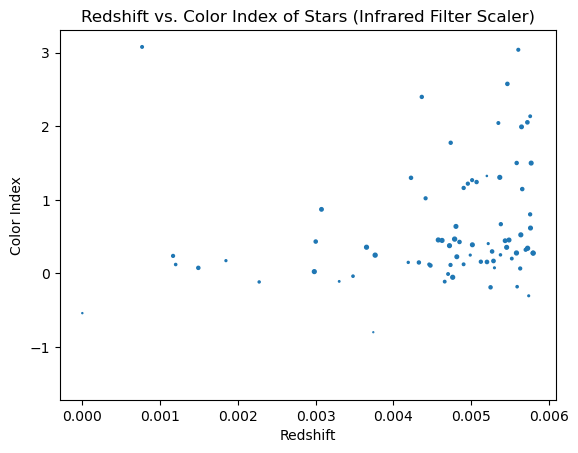

In [ ]:
#Plot scatter plot depicting relationship ebtween redshift and redlight based on STAR

plt.scatter(star_redshift, star_inf_fil, s = star_inf_fil)
plt.title("Redshift vs. Color Index of Stars (Infrared Filter Scaler)")
plt.xlabel('Redshift')
plt.ylabel('Infrared Filter')
plt.show()

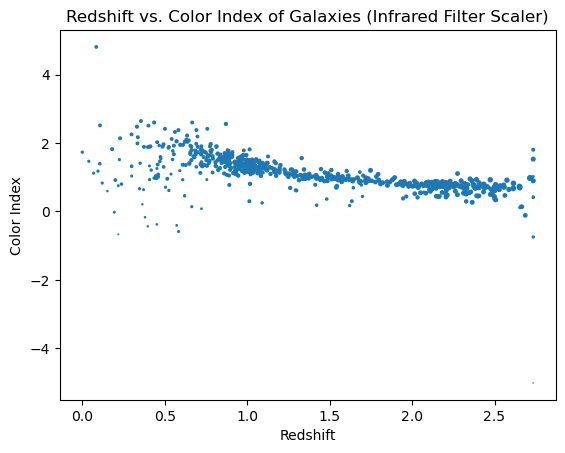

In [168]:
#Plot scatter plot depicting relationship ebtween redshift and redlight based on GALAXY

plt.scatter(galaxy_redshift, galaxy_ci, s = galaxy_inf_fil)
plt.title("Redshift vs. Color Index of Galaxies (Infrared Filter Scaler)")
plt.xlabel('Redshift')
plt.ylabel('Color Index')
plt.show()

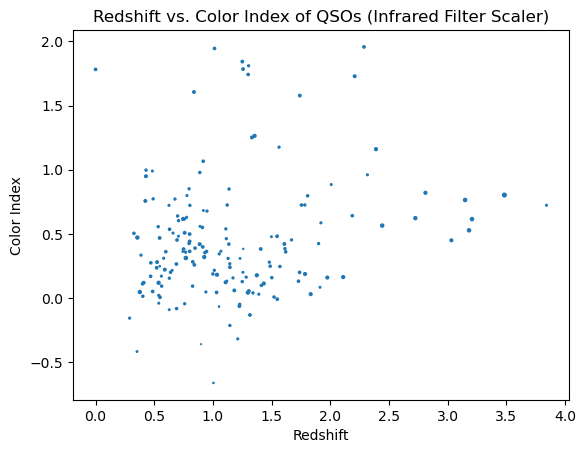

In [169]:
# Plot scatter plot depicting relationship ebtween redshift and redlight based on QSO

plt.scatter(qso_redshift, qso_ci, s = qso_inf_fil)
plt.title("Redshift vs. Color Index of QSOs (Infrared Filter Scaler)")
plt.xlabel('Redshift')
plt.ylabel('Color Index')
plt.show()

Russo's Mapping Function: Remember this for when you want to control duration! This is really, really important to experiment with if I want to expand the piece to three minutes. 

In [170]:
def map_value(value, min_value, max_value, min_result, max_result):
    '''maps value (or array of values) from one range to another'''
    
    result = min_result + (value - min_value)/(max_value - min_value)*(max_result - min_result) 
    # We're taking the range of values
    return result

Now, let's set a desired duration for three different graphs that we've created. Starting off with stars...

We're scaling 500.0 beats to an x-axis with a max of 4.0 (QSO has the max length for the x-axis)

In [171]:
duration_beats = 500.0 #desired duration in beats (actually, onset of last note)

qso_t_data = map_value(qso_redshift, 0, max(qso_redshift), 0, duration_beats)

qso_redshift_val_per_beat = max(qso_redshift)/duration_beats
print('QSO Redshift value per beat:', qso_redshift_val_per_beat)

QSO Redshift value per beat: 0.0076811916651820696


In [172]:
duration_beats = 375.0 #desired duration in beats (actually, onset of last note)

galaxy_t_data = map_value(galaxy_redshift, 0, max(galaxy_redshift), 0, duration_beats)

galaxy_redshift_val_per_beat = max(galaxy_redshift)/duration_beats
print('Galaxy Redshift value per beat:', galaxy_redshift_val_per_beat)

Galaxy Redshift value per beat: 0.007292519415669455


In [173]:
duration_beats = 0.75 #desired duration in beats (actually, onset of last note)

star_t_data = map_value(star_redshift, 0, max(star_redshift), 0, duration_beats)

star_redshift_val_per_beat = max(star_redshift)/duration_beats
print('Star Redshift value per beat:', star_redshift_val_per_beat)

Star Redshift value per beat: 0.007729418317901526


Now, I'm going to plot each graph to see what they look like once they're scaled to the right bpm (while also making sure the x-axis is essentially the same for all three graphs)

Duration: 0.75 seconds


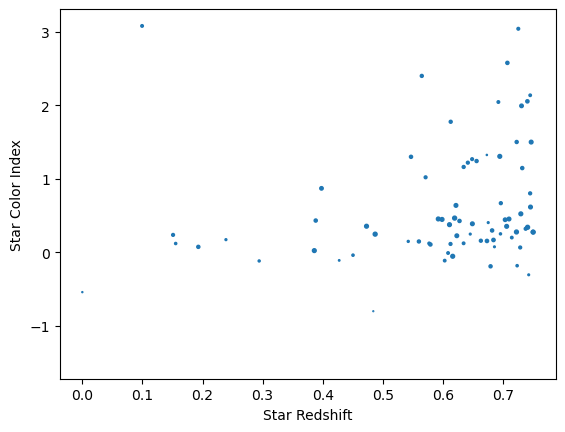

In [174]:
#calculate duration in seconds
bpm = 90  #if bpm = 90, 1 beat = 1 sec 
duration_sec = duration_beats*90/bpm #duration in seconds (actually, onset of last note)
print('Duration:', duration_sec, 'seconds')


plt.scatter(star_t_data, star_ci, s=star_inf_fil)
plt.xlabel('Star Redshift')
plt.ylabel('Star Color Index')
plt.show()

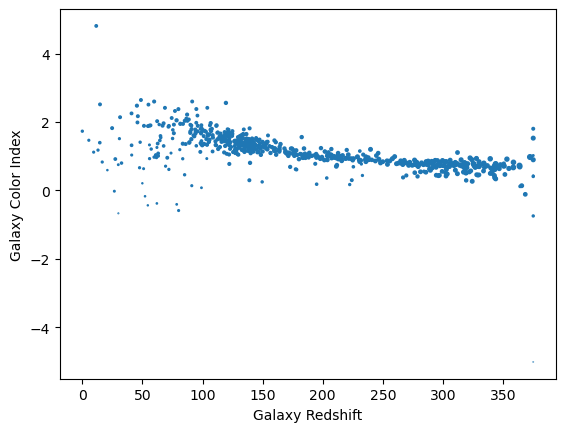

In [175]:
#calculate duration in seconds for galaxy

plt.scatter(galaxy_t_data, galaxy_ci, s=galaxy_inf_fil)
plt.xlabel('Galaxy Redshift')
plt.ylabel('Galaxy Color Index')
plt.show()

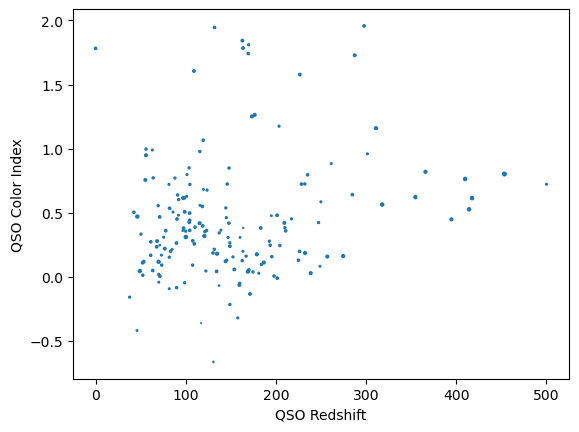

In [176]:
#calculate duration in seconds for qso

plt.scatter(qso_t_data, qso_ci, s=qso_inf_fil)
plt.xlabel('QSO Redshift')
plt.ylabel('QSO Color Index')
plt.show()

## Normalization and Scaling 

Might consider scaling x-axis as well given how bunched up the values look. Worst comes to worst, I could just cut down the dataset to prevent clumping or too much 'noise' from coming through. 

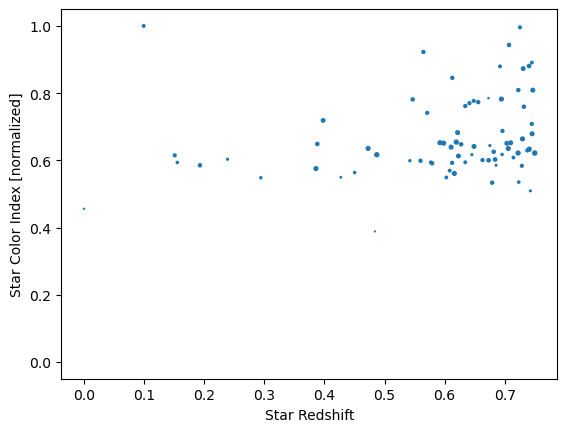

In [177]:
#Normalazing and scaling data for stars

y_scale = 0.5  #lower than 1 to spread out more evenly

star_y_data = map_value(star_ci, min(star_ci), max(star_ci), 0, 1) #normalize data, so it runs from 0 to 1 

star_y_data = star_y_data**y_scale

y_scale = 0.5  #lower than 1 to spread out more evenly

y_data = star_y_data**y_scale

plt.scatter(star_t_data, star_y_data, s=star_inf_fil)
plt.xlabel('Star Redshift')
plt.ylabel('Star Color Index [normalized]')
plt.show()

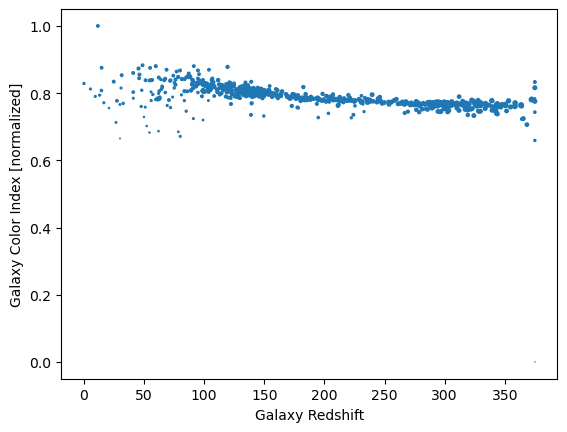

In [178]:
#Normalazing and scaling data for galaxies

galaxy_y_data = map_value(galaxy_ci, min(galaxy_ci), max(galaxy_ci), 0, 1) #normalize data, so it runs from 0 to 1 

galaxy_y_data = galaxy_y_data**y_scale

plt.scatter(galaxy_t_data, galaxy_y_data, s=galaxy_inf_fil)
plt.xlabel('Galaxy Redshift')
plt.ylabel('Galaxy Color Index [normalized]')
plt.show()

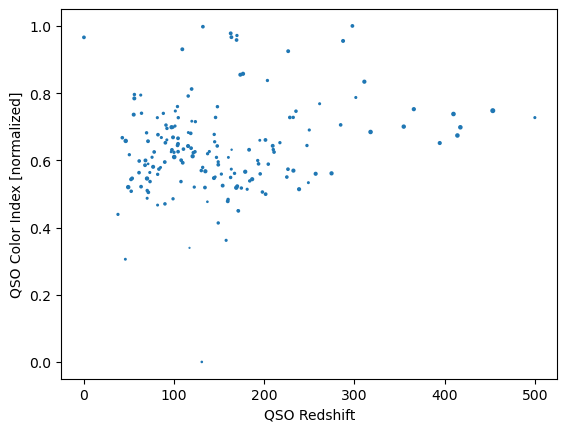

In [179]:
qso_y_data = map_value(qso_ci, min(qso_ci), max(qso_ci), 0, 1) #normalize data, so it runs from 0 to 1 

qso_y_data = qso_y_data**y_scale

plt.scatter(qso_t_data, qso_y_data, s=qso_inf_fil)
plt.xlabel('QSO Redshift')
plt.ylabel('QSO Color Index [normalized]')
plt.show()

## Now we're pitch mapping!

For this particular piece, I want to try and map non-western pitches/non-western scales onto data points?

I may not have a specific non-western scale in mind (I can attempt ragas and immitate the transitions and inflections of sound often reflected in gamakam, but I don't know how accurately sonification can do that)

Nevertheless, I want to first try and play around with audiolazy and see if it's possible for me to not have to round integers corresponding to pitch values. 

In [180]:
import itertools as it
from audiolazy_functions import *

MIDI_A4 = 69 #Note that MIDI note numbers are integers

def str2midi(note_string):
    """Given a note string name (e.g. "Bb4"), returns its MIDI pitch number. (From audiolazy)
    """
    
    data = note_string.strip().lower()
    name2delta = {"c": -9, "d": -7, "e": -5, "f": -4, "g": -2, "a": 0, "b": 2}
    accident2delta = {"b": -1, "#": 1, "x": 2}
    accidents = list(it.takewhile(lambda el: el in accident2delta, data[1:]))
    octave_delta = int(data[len(accidents) + 1:]) - 4
    return (MIDI_A4 +
          name2delta[data[0]] + # Name
          sum(accident2delta[ac] for ac in accidents) + # Accident
          12 * octave_delta # Octave
         )

In [181]:
#from audiolazy import str2midi #import function to convert note names to midi numbers (could also use: midi2str, str2freq, freq2str,freq2midi,midi2freq) https://pypi.org/project/audiolazy/
#removed due to problems importing it with some versions of python


#4 octaves of major pentatonic scale 
pent_note_names = ['F2','G2','A2','C2','D2',
             'F3','G3','A3','C3','D3',
             'F4','G4','A4','C4','D4',
             'F5','G5','A5','C5','D5']


chord_note_names = ['F1','F2','C2',
             'F3','A3','C3','D3','E3',
             'G4','A4','C4','D4','E4',
             'G5','A5','C5','D5','E5',
             'G6','A6','Bb6','C6','D6']


#UNIQUE TO THESE FILES 
octave_note_names = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']

#If I want to accurately represent the data, I should consider using as many notes as possible --> multiple combinations I don't have to worry about rounding to. 

all_note_names = ['A1','A#1','B1','C1','C#1','D1','D#1','E1','F1','F#1','G1','G#1',
             'A2','A#2','B2','C2','C#2','D2','D#2','E2','F2','F#2','G2','G#2',
             'A3','A#3','B3','C3','C#3','D3','D#3','E3','F3','F#3','G3','G#3',
             'A4','A#4','B4','C4','C#4','D4','D#4','E4','F4','F#4','G4','G#4',
             'A5','A#5','B5','C5','C#5','D5','D#5','E5','F5','F#5','G5','G#5',
             'A6','A#6','B6','C6','C#6','D6','D#6','E6','F6','F#6','G6','G#6',
             'A7','A#7','B7','C7','C#7','D7','D#7','E7','F7','F#7','G7','G#7',
             ]

note_midis = [str2midi(n) for n in all_note_names] #make a list of midi note numbers 

#Major scale is not the best choice because some notes are too close to each other. Second best choice 
# would be the Major Pentatonic. --> note that we can also map data to a certain chord

n_notes = len(note_midis)
print('Resolution:',n_notes, 'notes')

Resolution: 84 notes


### Now, let's create midi maps for each class we've normalized and scaled for

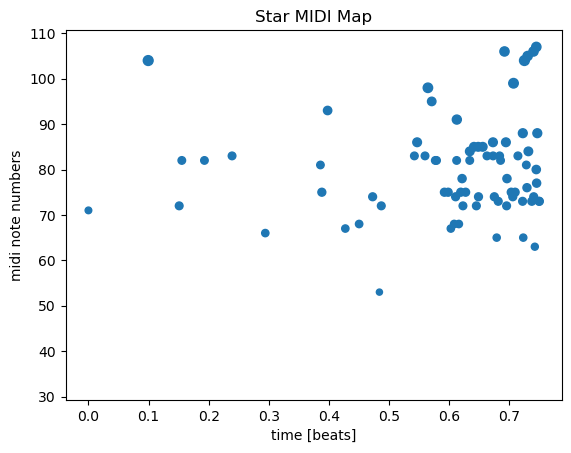

In [182]:
#Here's a MIDI Map for STAR Data

star_midi_data = []
for i in range(len(stars)): #For every impact, we're running map_value, will take current value, then map it to a new range, then go down the list all the way to zero.
    note_index = round(map_value(star_y_data[i], 0, 1, 0, n_notes-1)) #notice choice of polarity: bigger craters are mapped to lower notes
                                                        #we round the result because it's a list index which must be an integer
                                                        #What happens if you DON'T Round these values? What frequences can you hear? Can h
    star_midi_data.append(note_midis[note_index])

plt.scatter(star_t_data, star_midi_data, s=50*star_y_data)
plt.title('Star MIDI Map')
plt.xlabel('time [beats]')
plt.ylabel('midi note numbers')
plt.show()

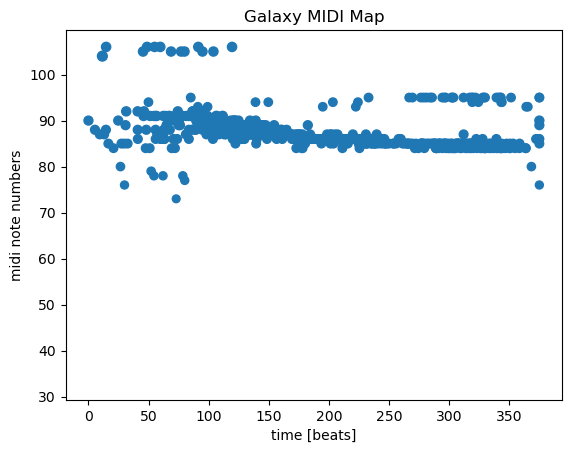

In [183]:
#Here's a MIDI Map for GALAXY Data

galaxy_midi_data = []
for i in range(len(galaxy)): #For every impact, we're running map_value, will take current value, then map it to a new range, then go down the list all the way to zero.
    note_index = round(map_value(galaxy_y_data[i], 0, 1, 0, n_notes-1)) #notice choice of polarity: bigger craters are mapped to lower notes
                                                        #we round the result because it's a list index which must be an integer
                                                        #What happens if you DON'T Round these values? What frequences can you hear? Can h
    galaxy_midi_data.append(note_midis[note_index])

plt.scatter(galaxy_t_data, galaxy_midi_data, s=50*galaxy_y_data)
plt.title('Galaxy MIDI Map')
plt.xlabel('time [beats]')
plt.ylabel('midi note numbers')
plt.show()

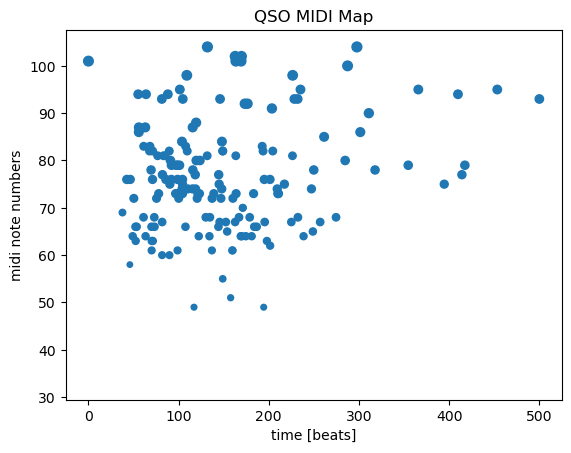

In [184]:
#Here's a MIDI Map for QSO Data

qso_midi_data = []
for i in range(len(qso)): #For every impact, we're running map_value, will take current value, then map it to a new range, then go down the list all the way to zero.
    note_index = round(map_value(qso_y_data[i], 0, 1, 0, n_notes-1)) #notice choice of polarity: bigger craters are mapped to lower notes
                                                        #we round the result because it's a list index which must be an integer
                                                        #What happens if you DON'T Round these values? What frequences can you hear? Can h
    qso_midi_data.append(note_midis[note_index])

plt.scatter(qso_t_data, qso_midi_data, s=50*qso_y_data)
plt.title('QSO MIDI Map')
plt.xlabel('time [beats]')
plt.ylabel('midi note numbers')
plt.show()

### Now, let's map note velocities for each graph

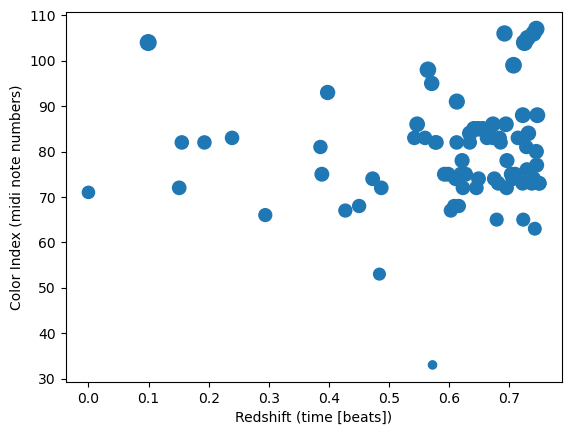

In [186]:
vel_min,vel_max = 35,127   #minimum and maximum note velocity


star_vel_data = []
for i in range(len(stars)):
    note_velocity = round(map_value(star_y_data[i], 0, 1, vel_min, vel_max)) #In this case, larger stellar objects will be louder
                                                                #we round here because note velocites are integers
    star_vel_data.append(note_velocity)
    
plt.scatter(star_t_data, star_midi_data, s=star_vel_data)
plt.xlabel('Redshift (time [beats])')
plt.ylabel('Color Index (midi note numbers)')
plt.show()

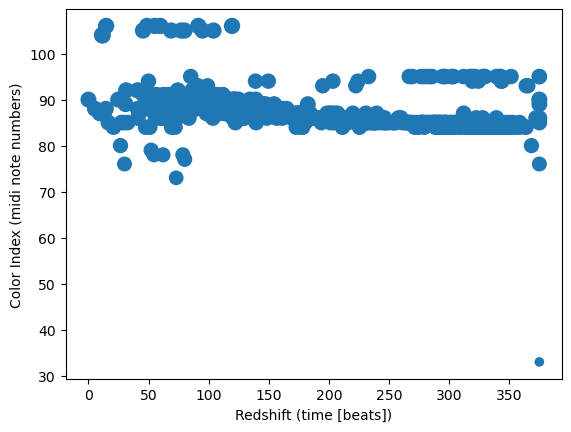

In [187]:
galaxy_vel_data = []
for i in range(len(galaxy)):
    note_velocity = round(map_value(galaxy_y_data[i], 0, 1, vel_min, vel_max)) #In this case, larger stellar objects will be louder
                                                                #we round here because note velocites are integers
    galaxy_vel_data.append(note_velocity)
    
plt.scatter(galaxy_t_data, galaxy_midi_data, s=galaxy_vel_data)
plt.xlabel('Redshift (time [beats])')
plt.ylabel('Color Index (midi note numbers)')
plt.show()

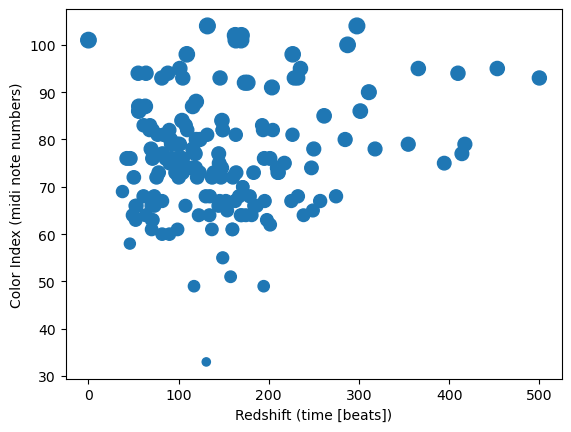

In [188]:
qso_vel_data = []
for i in range(len(qso)):
    note_velocity = round(map_value(qso_y_data[i], 0, 1, vel_min, vel_max)) #In this case, larger stellar objects will be louder
                                                                #we round here because note velocites are integers
    qso_vel_data.append(note_velocity)
    
plt.scatter(qso_t_data, qso_midi_data, s=qso_vel_data)
plt.xlabel('Redshift (time [beats])')
plt.ylabel('Color Index (midi note numbers)')
plt.show()

Let's create three separate MIDI files

In [189]:
%pip install MIDIUtil

import sys
print(sys.executable)

stars.to_csv('stars.csv', index=False)
stars_file = 'stars.csv'

from midiutil import MIDIFile #import library to make midi file, https://midiutil.readthedocs.io/en/1.2.1/
    
#create midi file object, add tempo
star_midi_file = MIDIFile(1) #one track 
star_midi_file.addTempo(track=0, time=0, tempo=bpm) 

#add midi notes
for i in range(len(stars)):
    star_midi_file.addNote(track=0, channel=0, pitch=star_midi_data[i], time=star_t_data[i], duration=2, volume=star_vel_data[i])

#create and save the midi file itself
with open(stars_file.replace('.csv', '.mid'), "wb") as f:
    star_midi_file.writeFile(f) 

Note: you may need to restart the kernel to use updated packages.
c:\Users\Owner\anaconda3\python.exe


In [190]:
%pip install MIDIUtil

import sys
print(sys.executable)

galaxy.to_csv('galaxy.csv', index=False)
galaxy_file = 'galaxy.csv'

from midiutil import MIDIFile #import library to make midi file, https://midiutil.readthedocs.io/en/1.2.1/

#create midi file object, add tempo
galaxy_midi_file = MIDIFile(1) #one track 
galaxy_midi_file.addTempo(track=0, time=0, tempo=bpm) 

#add midi notes
for i in range(len(galaxy)):
    galaxy_midi_file.addNote(track=0, channel=0, pitch=galaxy_midi_data[i], time=galaxy_t_data[i], duration=2, volume=galaxy_vel_data[i])

#create and save the midi file itself
with open(galaxy_file.replace('.csv', '.mid'), "wb") as f:
    galaxy_midi_file.writeFile(f) 

Note: you may need to restart the kernel to use updated packages.
c:\Users\Owner\anaconda3\python.exe


In [191]:
%pip install MIDIUtil

import sys
print(sys.executable)

qso.to_csv('qso.csv', index=False)
qso_file = 'qso.csv'

from midiutil import MIDIFile #import library to make midi file, https://midiutil.readthedocs.io/en/1.2.1/

#create midi file object, add tempo
qso_midi_file = MIDIFile(1) #one track 
qso_midi_file.addTempo(track=0, time=0, tempo=bpm) 

#add midi notes
for i in range(len(qso)):
    qso_midi_file.addNote(track=0, channel=0, pitch=qso_midi_data[i], time=qso_t_data[i], duration=2, volume=qso_vel_data[i])

#create and save the midi file itself
with open(qso_file.replace('.csv', '.mid'), "wb") as f:
    qso_midi_file.writeFile(f) 

Note: you may need to restart the kernel to use updated packages.
c:\Users\Owner\anaconda3\python.exe
